In [45]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 3.0.3
numpy version: 2.5.1


In [46]:
df = pd.read_csv('marketing_AB.csv')
print("Shape:", df.shape)
df.head()

Shape: (588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [47]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nInfo:")
df.columns = df.columns.str.strip().str.replace(' ', '_')
df.info()
print("\nNulls:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nNumeric summary:\n", df.describe())
print("\nCategorical summary:\n", df.describe(include='object'))
print("\ntest_group counts:\n", df['test_group'].value_counts())

print("\ntest_group split %:")
print(df['test_group'].value_counts(normalize=True) * 100)

Shape: (588101, 7)

Dtypes:
 Unnamed: 0       int64
user id          int64
test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed:_0     588101 non-null  int64
 1   user_id        588101 non-null  int64
 2   test_group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total_ads      588101 non-null  int64
 5   most_ads_day   588101 non-null  str  
 6   most_ads_hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB

Nulls:
 Unnamed:_0       0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

Duplicates: 0

Numeric summary:
           Unnamed:_0       user_id      total_ads  most_ad

In [48]:
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['unnamed:_0', 'user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']


In [49]:
# converted_int
df['converted_int'] = df['converted'].astype(int)

# is_weekend
weekend_days = ['Saturday', 'Sunday']
df['is_weekend'] = df['most_ads_day'].isin(weekend_days).astype('int8')

# hour_period — ordered category
def hour_to_period(h):
    if 5 <= h < 12:
        return 'morning'
    elif 12 <= h < 17:
        return 'afternoon'
    elif 17 <= h < 21:
        return 'evening'
    else:
        return 'night'

df['hour_period'] = df['most_ads_hour'].apply(hour_to_period)

from pandas.api.types import CategoricalDtype
hour_cat = CategoricalDtype(categories=['morning','afternoon','evening','night'], ordered=True)
df['hour_period'] = df['hour_period'].astype(hour_cat)

# ads_bucket — fixed with duplicates='drop'
df['ads_bucket'] = pd.qcut(df['total_ads'], q=4, labels=['low','medium','high','very_high'], duplicates='drop')

df.head()

,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,converted_int,is_weekend,hour_period,ads_bucket
0,0,1069124,ad,False,130,Monday,20,0,0,evening,very_high
1,1,1119715,ad,False,93,Tuesday,22,0,0,night,very_high
2,2,1144181,ad,False,21,Tuesday,18,0,0,evening,high
3,3,1435133,ad,False,355,Tuesday,10,0,0,morning,very_high
4,4,1015700,ad,False,276,Friday,14,0,0,afternoon,very_high


In [50]:
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory before: {mem_before:.2f} MB")

df['test_group'] = df['test_group'].astype('category')
df['most_ads_day'] = df['most_ads_day'].astype('category')
df['converted_int'] = df['converted_int'].astype('int8')
df['is_weekend'] = df['is_weekend'].astype('int8')
df['most_ads_hour'] = df['most_ads_hour'].astype('int8')
df['total_ads'] = pd.to_numeric(df['total_ads'], downcast='integer')

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory after: {mem_after:.2f} MB")
print(f"Reduction: {(1 - mem_after/mem_before)*100:.1f}%")

Memory before: 84.77 MB
Memory after: 14.58 MB
Reduction: 82.8%


In [51]:
print("Final shape:", df.shape)
print("\nFinal dtypes:\n", df.dtypes)
print("\nFinal nulls:\n", df.isnull().sum())
print("Final duplicates:", df.duplicated().sum())

df.to_csv('marketing_AB_cleaned.csv', index=False)
print("\n✅ Saved as marketing_AB_cleaned.csv")

Final shape: (588101, 11)

Final dtypes:
 unnamed:_0          int64
user_id             int64
test_group       category
converted            bool
total_ads           int16
most_ads_day     category
most_ads_hour        int8
converted_int        int8
is_weekend           int8
hour_period      category
ads_bucket       category
dtype: object

Final nulls:
 unnamed:_0       0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
converted_int    0
is_weekend       0
hour_period      0
ads_bucket       0
dtype: int64
Final duplicates: 0

✅ Saved as marketing_AB_cleaned.csv


In [52]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [53]:
df = pd.read_csv("marketing_AB_cleaned.csv")

In [54]:
df.index.min()

0

In [55]:
df.index.max()

588100

In [56]:
df.columns

Index(['unnamed:_0', 'user_id', 'test_group', 'converted', 'total_ads',
       'most_ads_day', 'most_ads_hour', 'converted_int', 'is_weekend',
       'hour_period', 'ads_bucket'],
      dtype='str')

In [57]:
df = df.dropna(subset=["converted"]).copy()

df["converted_int"] = df["converted"].astype(int)

In [58]:
df["test_group"].value_counts()

(df["test_group"].value_counts(normalize=True) * 100).round(2)

test_group
ad     96.0
psa     4.0
Name: proportion, dtype: float64

## Chi-Square Test
Evaluate whether conversion rates differ significantly between the Ads and PSA groups.

In [59]:
contingency = pd.crosstab(df["test_group"], df["converted_int"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

contingency
print("\nChi-square:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value)


Chi-square: 54.005823883685245
Degrees of freedom: 1
P-value: 1.9989623063390075e-13


**H₀:** Conversion rates are the same for both groups.  
**H₁:** Conversion rates are different between the two groups.

In [60]:
summary = df.groupby("test_group")["converted_int"].agg(
    conversions="sum",
    total="count"
)

summary["conversion_rate"] = (
    summary["conversions"] / summary["total"]
)

summary

,conversions,total,conversion_rate
test_group,,,
ad,14423,564577,0.025547
psa,420,23524,0.017854


## Cohen's h
Measure the practical effect size of the difference in conversion rates.

In [61]:
control_rate = summary.loc["psa", "conversion_rate"]
test_rate = summary.loc["ad", "conversion_rate"]

cohen_h = proportion_effectsize(control_rate, test_rate)

print("Cohen's h:", cohen_h)

Cohen's h: -0.053002578606030915


## 95% Confidence Interval
Estimate the range in which the true conversion rate for each group is likely to fall.

In [62]:
for group in summary.index:
    low, high = proportion_confint(
        count=summary.loc[group, "conversions"],
        nobs=summary.loc[group, "total"],
        alpha=0.05,
        method="wilson"
    )

    print(f"{group}:")
    print(f"95% CI = ({low:.4%}, {high:.4%})\n")

ad:
95% CI = (2.5138%, 2.5961%)

psa:
95% CI = (1.6239%, 1.9627%)



## Group Imbalance Analysis
Assess whether the unequal sample sizes between the Ads and PSA groups could impact the analysis.

## Statistical Power Analysis
Evaluate whether the experiment has sufficient power to detect a meaningful difference in conversion rates.

In [63]:
analysis = NormalIndPower()
effect_size = proportion_effectsize(control_rate, test_rate)
power = analysis.power(
    effect_size=effect_size,
    nobs1=summary.loc["psa", "total"],
    ratio=summary.loc["ad", "total"] / summary.loc["psa", "total"],
    alpha=0.05
)

print("Statistical Power:", power)

Statistical Power: 0.9999999990438161


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

## Dose-Response Curve
Analyze how conversion rate changes as the number of ads viewed increases.

In [65]:
dose_response = (
    df.groupby("total_ads")["converted_int"]
      .mean()
      .reset_index()
)

dose_response.head()

,total_ads,converted_int
0,1,0.001572
1,2,0.002360
2,3,0.002826
3,4,0.003586
4,5,0.003447


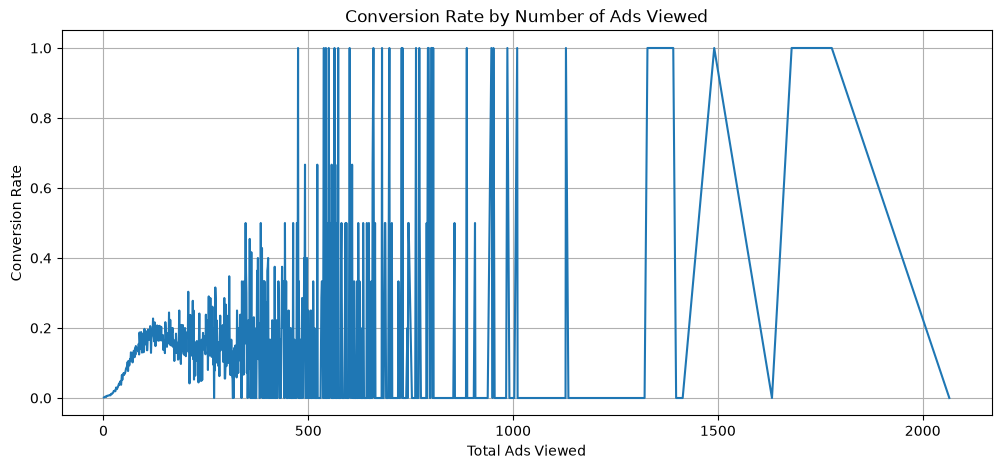

In [66]:
plt.figure(figsize=(12,5))

plt.plot(
    dose_response["total_ads"],
    dose_response["converted_int"],
)

plt.title("Conversion Rate by Number of Ads Viewed")
plt.xlabel("Total Ads Viewed")
plt.ylabel("Conversion Rate")

plt.grid(True)

plt.show()

## Hourly Conversion Analysis
Visualize conversion rates by hour to identify peak and low-performing time periods.

In [67]:
hourly_conversion = (
    df.groupby("most_ads_hour")["converted_int"]
      .mean()
      .reset_index()
)

hourly_conversion.head()

,most_ads_hour,converted_int
0,0,0.018425
1,1,0.012911
2,2,0.007313
3,3,0.010452
4,4,0.015235


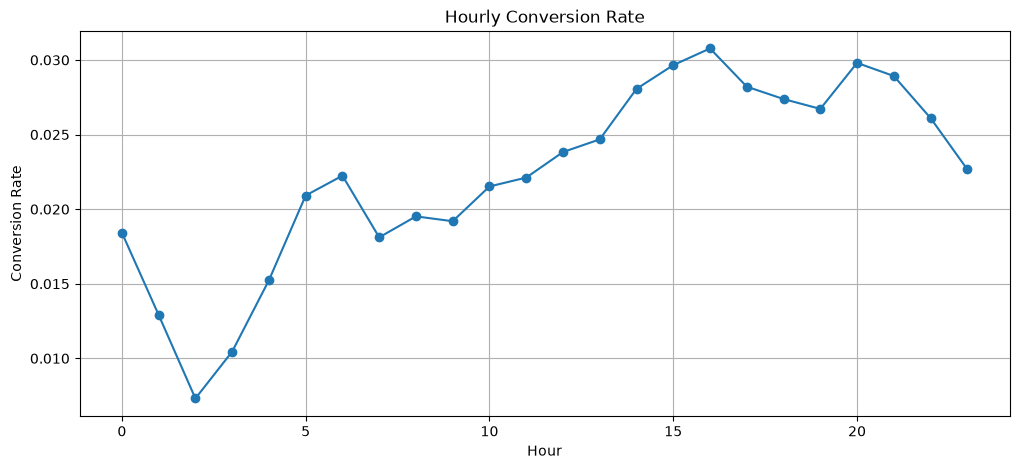

In [68]:
plt.figure(figsize=(12,5))

plt.plot(
    hourly_conversion["most_ads_hour"],
    hourly_conversion["converted_int"],
    marker="o"
)

plt.title("Hourly Conversion Rate")
plt.xlabel("Hour")
plt.ylabel("Conversion Rate")
plt.grid(True)
plt.show()

In [69]:
peak = hourly_conversion.loc[
    hourly_conversion["converted_int"].idxmax()
]

lowest = hourly_conversion.loc[
    hourly_conversion["converted_int"].idxmin()
]

print("Peak Hour")
print(peak)
print()
print("Lowest Hour")
print(lowest)

Peak Hour
most_ads_hour    16.000000
converted_int     0.030772
Name: 16, dtype: float64

Lowest Hour
most_ads_hour    2.000000
converted_int    0.007313
Name: 2, dtype: float64


## Day × Hour Heatmap
Examine conversion patterns across days and hours to identify scheduling opportunities and anomalies.

In [70]:
heatmap_data = pd.pivot_table(
    df,
    values="converted_int",
    index="most_ads_day",
    columns="most_ads_hour",
    aggfunc="mean"
)

heatmap_data.head()

most_ads_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
most_ads_day,,,,,,,,,,,,,,,,,,,,,
Friday,0.019025,0.010130,0.011765,0.003690,0.016393,0.014815,0.011662,0.018657,0.016207,0.019634,...,0.023658,0.026244,0.026892,0.021598,0.024197,0.021370,0.029796,0.029440,0.020525,0.017419
Monday,0.016241,0.015901,0.006784,0.012121,0.000000,0.031915,0.039427,0.017812,0.032669,0.026177,...,0.044357,0.042490,0.037043,0.035733,0.027395,0.030736,0.031746,0.032932,0.029390,0.023882
Saturday,0.022756,0.008274,0.004296,0.010695,0.000000,0.053191,0.049057,0.023873,0.022860,0.015898,...,0.019643,0.021671,0.019831,0.022329,0.025272,0.026276,0.023589,0.031981,0.024769,0.021821
Sunday,0.015707,0.016807,0.005634,0.018373,0.019608,0.015748,0.006944,0.019643,0.016333,0.016044,...,0.020039,0.023140,0.027768,0.031463,0.029908,0.035577,0.043165,0.036188,0.030854,0.028571
Thursday,0.023936,0.017931,0.012465,0.005391,0.026087,0.020833,0.019802,0.015023,0.015723,0.016003,...,0.025488,0.024752,0.026616,0.021260,0.022848,0.023781,0.028148,0.020923,0.022396,0.020137


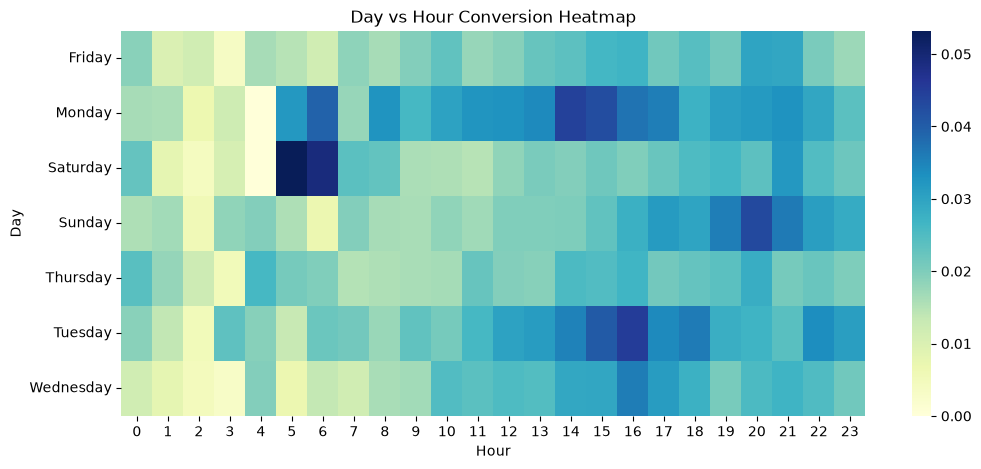

In [71]:
plt.figure(figsize=(12,5))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)
plt.title("Day vs Hour Conversion Heatmap")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

## Business Impact Calculation
Estimate the incremental conversions and business impact generated by the advertising campaign.

In [72]:
summary = df.groupby("test_group")["converted_int"].agg(
    conversions="sum",
    total="count"
)

summary["conversion_rate"] = (
    summary["conversions"] /
    summary["total"]
)

summary

,conversions,total,conversion_rate
test_group,,,
ad,14423,564577,0.025547
psa,420,23524,0.017854


In [73]:
ad_rate = summary.loc["ad", "conversion_rate"]
psa_rate = summary.loc["psa", "conversion_rate"]

lift = ad_rate - psa_rate

print("Ads Conversion Rate :", round(ad_rate,4))
print("PSA Conversion Rate :", round(psa_rate,4))
print("Incremental Lift :", round(lift,4))

Ads Conversion Rate : 0.0255
PSA Conversion Rate : 0.0179
Incremental Lift : 0.0077


In [74]:
ad_users = summary.loc["ad", "total"]
extra_conversions = lift * ad_users
print("Estimated Additional Conversions")
round(extra_conversions)

Estimated Additional Conversions


4343

In [75]:
impact = pd.DataFrame({
    "Metric":[
        "Ads Conversion Rate",
        "PSA Conversion Rate",
        "Incremental Lift",
        "Estimated Additional Conversions"
    ],
    "Value":[
        ad_rate,
        psa_rate,
        lift,
        round(extra_conversions)
    ]
})

impact

,Metric,Value
0,Ads Conversion Rate,0.025547
1,PSA Conversion Rate,0.017854
2,Incremental Lift,0.007692
3,Estimated Additional Conversions,4343.000000
